<a href="https://colab.research.google.com/github/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/blob/main/Modelo_PropensionCompra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MODELO DE MACHINE LEARNING DE PROPENSION DE COMPRA**

**1.ANALISIS EXPLORATORIO DE DATOS (EDA)**

In [ ]:
import pandas as pd
import numpy as np

# URL del archivo en GitHub
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"

# Cargar dataset
df = pd.read_csv(url)

# Ver primeras filas
df.head()

,id,dia_visita,incidencia_compra,id_marca,cantidad,ultima_marca_comprada,ultima_cantidad_comprada,precio_marca_1,precio_marca_2,precio_marca_3,...,promo_marca_3,promo_marca_4,promo_marca_5,genero,estado_civil,edad,nivel_educacion,ingreso_anual,ocupacion,tamanio_ciudad
0,200000001,1,0,0,0,0,0,1.59,1.87,2.01,...,0,0,0,0,0,47,1,110866,1,0
1,200000001,11,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0
2,200000001,12,0,0,0,0,0,1.51,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0
3,200000001,16,0,0,0,0,0,1.52,1.89,1.98,...,0,0,0,0,0,47,1,110866,1,0
4,200000001,18,0,0,0,0,0,1.52,1.89,1.99,...,0,0,0,0,0,47,1,110866,1,0


In [34]:
# ==============================
# 1. LIBRERÍAS
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# 2. CARGA DE DATOS
# ==============================
# URL del archivo en GitHub
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"

# Cargar dataset
df = pd.read_csv(url)

print(df.head())
print(df.info())
print(df.describe())



          id  dia_visita  incidencia_compra  id_marca  cantidad  \
0  200000001           1                  0         0         0   
1  200000001          11                  0         0         0   
2  200000001          12                  0         0         0   
3  200000001          16                  0         0         0   
4  200000001          18                  0         0         0   

   ultima_marca_comprada  ultima_cantidad_comprada  precio_marca_1  \
0                      0                         0            1.59   
1                      0                         0            1.51   
2                      0                         0            1.51   
3                      0                         0            1.52   
4                      0                         0            1.52   

   precio_marca_2  precio_marca_3  ...  promo_marca_3  promo_marca_4  \
0            1.87            2.01  ...              0              0   
1            1.89            1.9

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# ESTILO
# =========================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# Paleta elegante
palette = sns.color_palette("Set2")

incidencia_compra
0    0.750601
1    0.249399
Name: proportion, dtype: float64


/tmp/ipykernel_10655/4169587291.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='incidencia_compra', data=df, palette=palette)
/tmp/ipykernel_10655/4169587291.py:6: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.countplot(x='incidencia_compra', data=df, palette=palette)


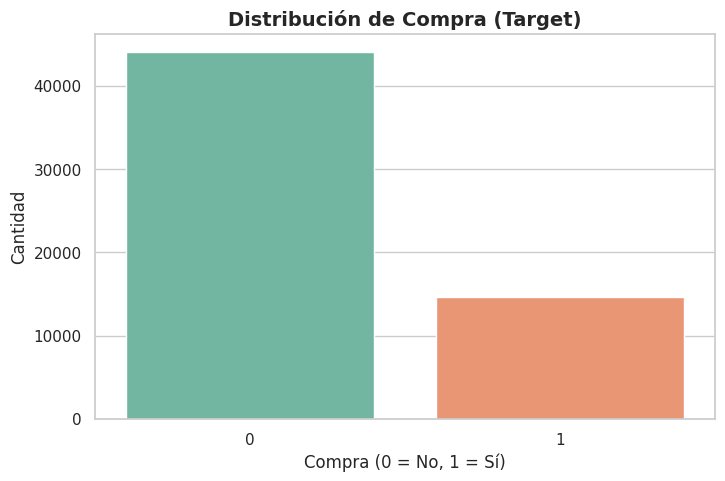

In [35]:
# =========================
# TARGET
# =========================
print(df['incidencia_compra'].value_counts(normalize=True))

sns.countplot(x='incidencia_compra', data=df, palette=palette)
plt.title("Distribución de Compra (Target)", fontsize=14, weight='bold')
plt.xlabel("Compra (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.show()

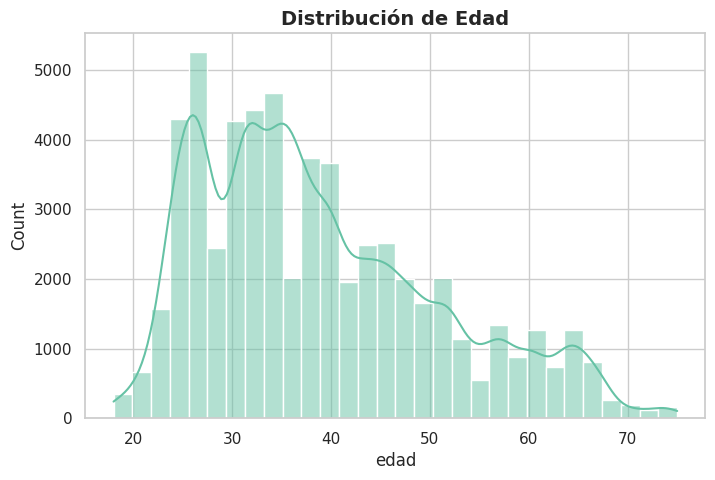

In [36]:
# =========================
# EDAD
# =========================
sns.histplot(df['edad'], bins=30, kde=True, color=palette[0])
plt.title("Distribución de Edad", fontsize=14, weight='bold')
plt.show()

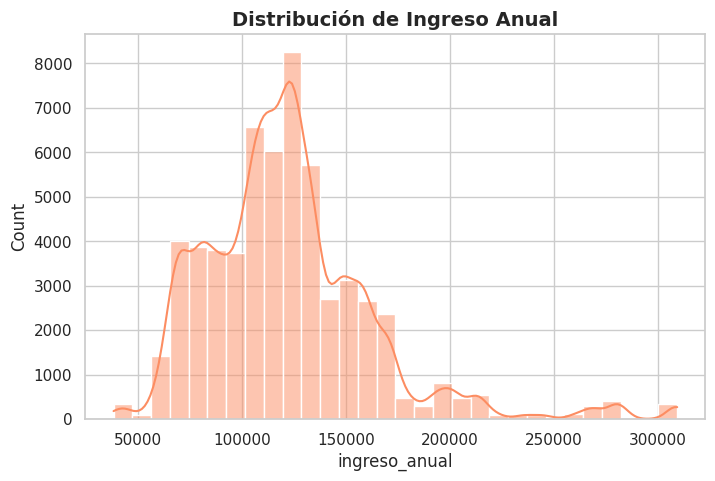

In [37]:
# =========================
# INGRESO
# =========================
sns.histplot(df['ingreso_anual'], bins=30, kde=True, color=palette[1])
plt.title("Distribución de Ingreso Anual", fontsize=14, weight='bold')
plt.show()


/tmp/ipykernel_10655/2897370601.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='id_marca', data=df, palette=palette)
/tmp/ipykernel_10655/2897370601.py:4: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.countplot(x='id_marca', data=df, palette=palette)


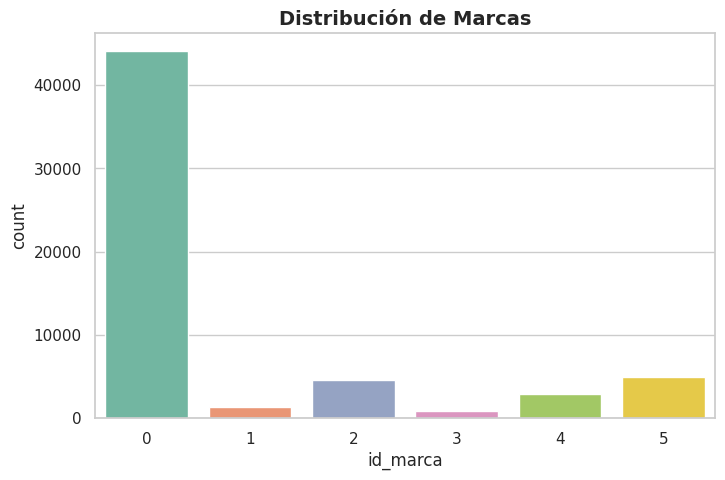

/tmp/ipykernel_10655/2897370601.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_10655/2897370601.py:9: UserWarning: The palette list has more values (8) than needed (6), which may not be intended.
  sns.barplot(


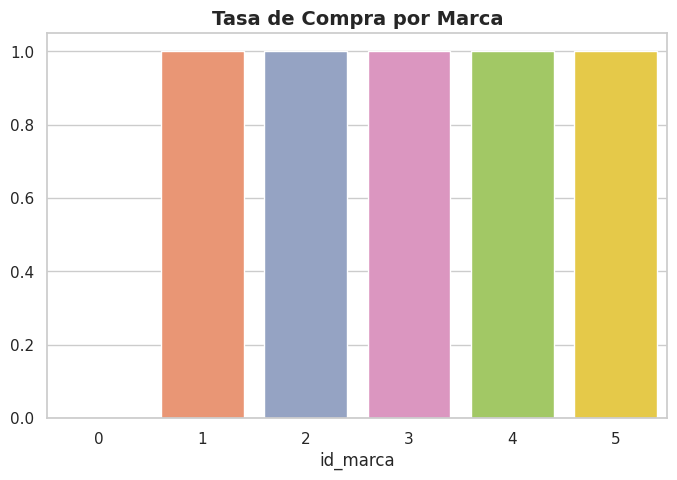

In [38]:
# =========================
# MARCAS
# =========================
sns.countplot(x='id_marca', data=df, palette=palette)
plt.title("Distribución de Marcas", fontsize=14, weight='bold')
plt.show()

# Tasa de compra por marca
sns.barplot(
    x=df.groupby('id_marca')['incidencia_compra'].mean().index,
    y=df.groupby('id_marca')['incidencia_compra'].mean().values,
    palette=palette
)
plt.title("Tasa de Compra por Marca", fontsize=14, weight='bold')
plt.show()


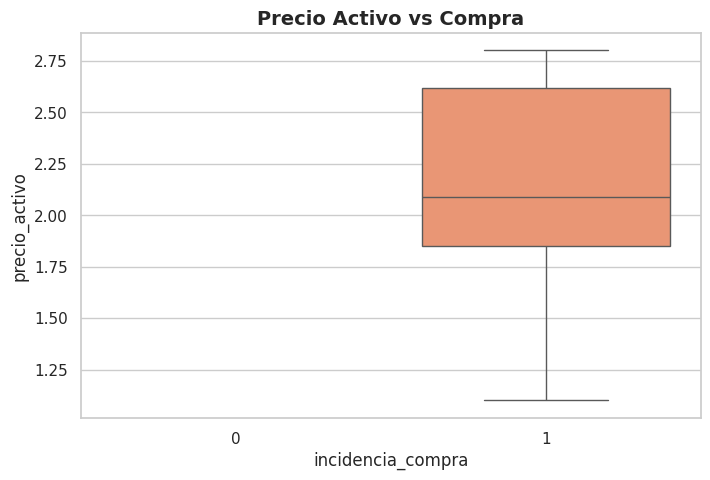

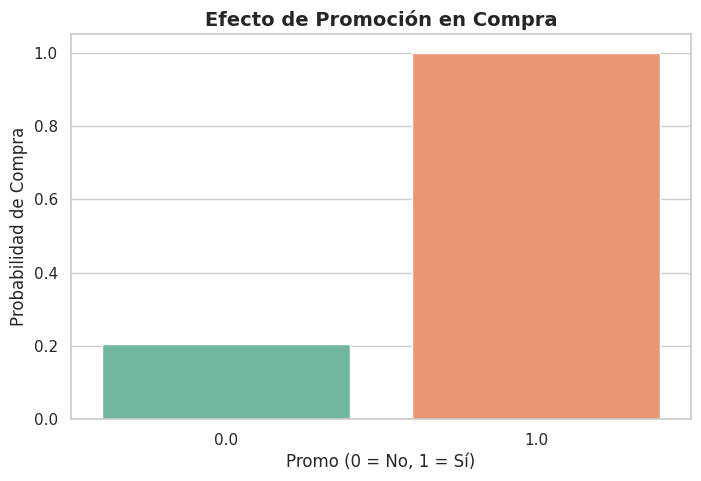

In [45]:
import numpy as np

# =========================
# VARIABLES ACTIVAS
# =========================
def get_active_price(row):
    if row['id_marca'] == 0:
        return np.nan  # Assign NaN if id_marca is 0 (no corresponding price column)
    return row[f'precio_marca_{int(row["id_marca"])}']

def get_active_promo(row):
    if row['id_marca'] == 0:
        return 0  # Assign 0 if id_marca is 0 (no corresponding promo column)
    return row[f'promo_marca_{int(row["id_marca"])}']

df['precio_activo'] = df.apply(get_active_price, axis=1)
df['promo_activa'] = df.apply(get_active_promo, axis=1)

# =========================
# PRECIO vs COMPRA
# =========================
sns.boxplot(x='incidencia_compra', y='precio_activo', data=df, hue='incidencia_compra', palette=palette[:2], legend=False)
plt.title("Precio Activo vs Compra", fontsize=14, weight='bold')
plt.show()

# =========================
# PROMOCIÓN
# =========================
promo = df.groupby('promo_activa')['incidencia_compra'].mean()

sns.barplot(x=promo.index, y=promo.values, hue=promo.index, palette=palette[:2], legend=False)
plt.title("Efecto de Promoción en Compra", fontsize=14, weight='bold')
plt.xlabel("Promo (0 = No, 1 = Sí)")
plt.ylabel("Probabilidad de Compra")
plt.show()

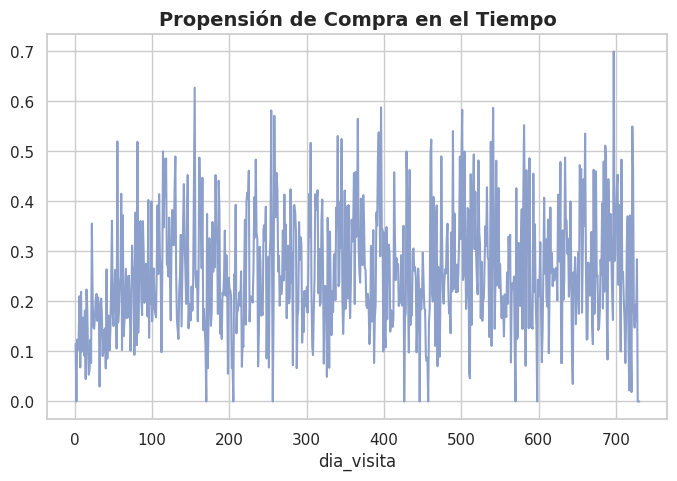

In [46]:
# =========================
# TIEMPO
# =========================
sns.lineplot(
    x=df.groupby('dia_visita')['incidencia_compra'].mean().index,
    y=df.groupby('dia_visita')['incidencia_compra'].mean().values,
    color=palette[2]
)
plt.title("Propensión de Compra en el Tiempo", fontsize=14, weight='bold')
plt.show()

/tmp/ipykernel_10655/4213918146.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='incidencia_compra', y='ultima_cantidad_comprada', data=df, palette=palette)
/tmp/ipykernel_10655/4213918146.py:4: UserWarning: The palette list has more values (8) than needed (2), which may not be intended.
  sns.boxplot(x='incidencia_compra', y='ultima_cantidad_comprada', data=df, palette=palette)


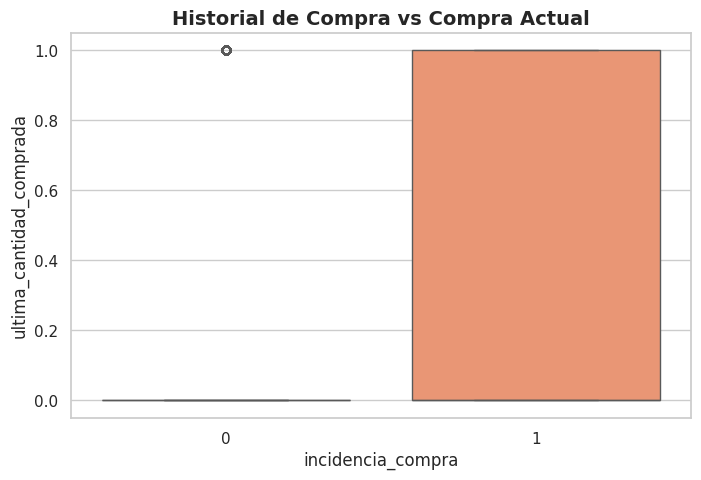

In [47]:
# =========================
# HISTORIAL
# =========================
sns.boxplot(x='incidencia_compra', y='ultima_cantidad_comprada', data=df, palette=palette)
plt.title("Historial de Compra vs Compra Actual", fontsize=14, weight='bold')
plt.show()

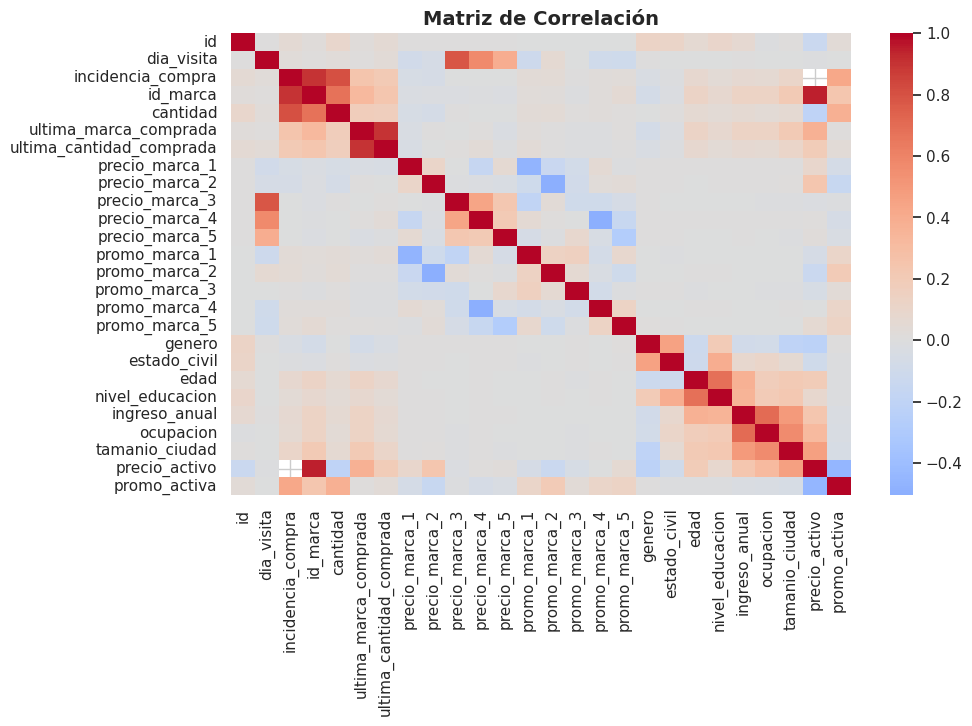

In [48]:
# =========================
# CORRELACIÓN
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Matriz de Correlación", fontsize=14, weight='bold')
plt.show()


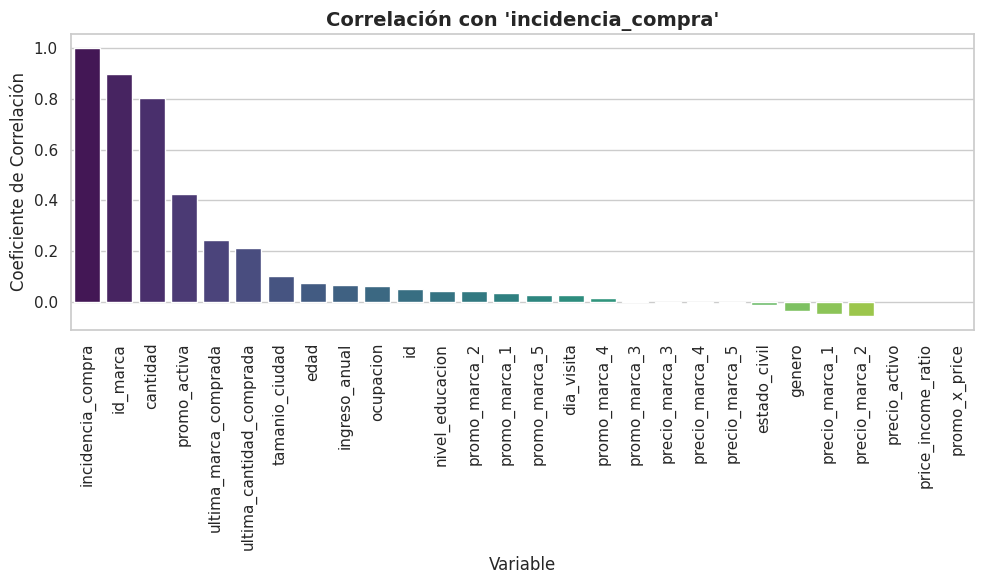

Correlación de las variables con 'incidencia_compra':
incidencia_compra           1.000000
id_marca                    0.896919
cantidad                    0.800987
promo_activa                0.425402
ultima_marca_comprada       0.245340
ultima_cantidad_comprada    0.212054
tamanio_ciudad              0.102785
edad                        0.074272
ingreso_anual               0.068995
ocupacion                   0.061943
id                          0.051820
nivel_educacion             0.043699
promo_marca_2               0.042206
promo_marca_1               0.034726
promo_marca_5               0.029650
dia_visita                  0.027664
promo_marca_4               0.018308
promo_marca_3               0.003017
precio_marca_3             -0.001171
precio_marca_4             -0.001841
precio_marca_5             -0.002945
estado_civil               -0.009384
genero                     -0.033865
precio_marca_1             -0.047535
precio_marca_2             -0.054927
precio_activo        

In [59]:
# Re-load the original dataset to ensure 'incidencia_compra' is present
url = "https://raw.githubusercontent.com/hurtadoadianet-code/MODELO_PROPENSION_COMPRA-/main/data/compras_data.csv"
df = pd.read_csv(url)

# Re-apply feature engineering for active price and promo
def get_active_price(row):
    if row['id_marca'] == 0:
        return np.nan
    return row[f'precio_marca_{int(row["id_marca"])}']

def get_active_promo(row):
    if row['id_marca'] == 0:
        return 0
    return row[f'promo_marca_{int(row["id_marca"])}']

df['precio_activo'] = df.apply(get_active_price, axis=1)
df['promo_activa'] = df.apply(get_active_promo, axis=1)

# Re-apply additional features that might be used in correlation
df['price_income_ratio'] = df['precio_activo'] / df['ingreso_anual']
df['promo_x_price'] = df['promo_activa'] * df['precio_activo']

correlations = df.corr(numeric_only=True)['incidencia_compra'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlations.index, y=correlations.values, palette='viridis', hue=correlations.index, legend=False)
plt.title("Correlación con 'incidencia_compra'", fontsize=14, weight='bold')
plt.xlabel("Variable")
plt.ylabel("Coeficiente de Correlación")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Correlación de las variables con 'incidencia_compra':")
print(correlations)

In [50]:
# =========================
# FEATURES BASE
# =========================
df['price_income_ratio'] = df['precio_activo'] / df['ingreso_anual']
df['promo_x_price'] = df['promo_activa'] * df['precio_activo']

print("EDA COMPLETADO")

EDA COMPLETADO


**2. MODELO DE PROSPECCION**

AUC: 1.0

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13217
           1       1.00      1.00      1.00      4391

    accuracy                           1.00     17608
   macro avg       1.00      1.00      1.00     17608
weighted avg       1.00      1.00      1.00     17608


Matriz de confusión:
[[13217     0]
 [    0  4391]]


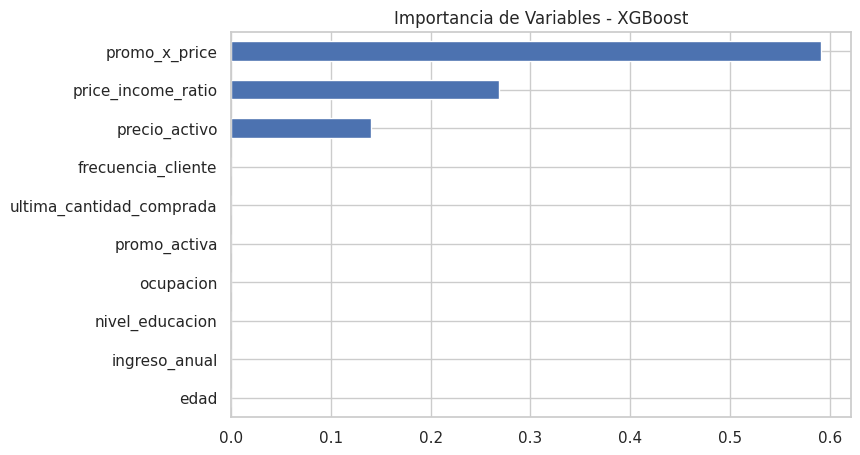

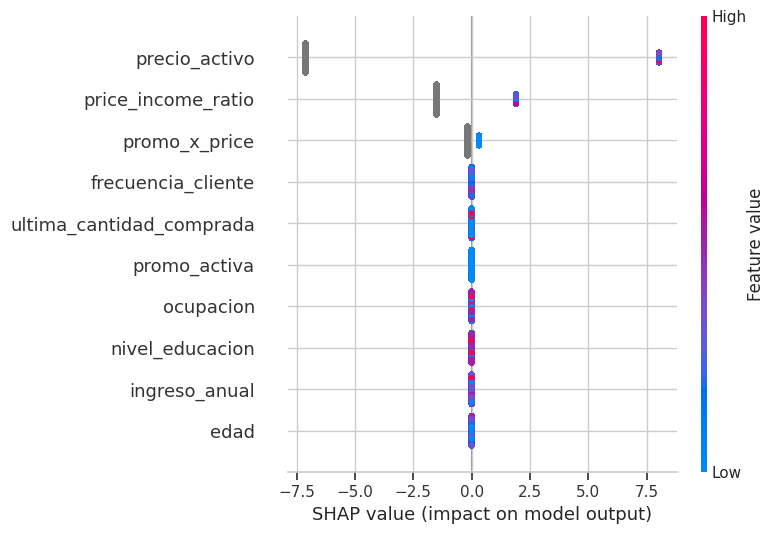

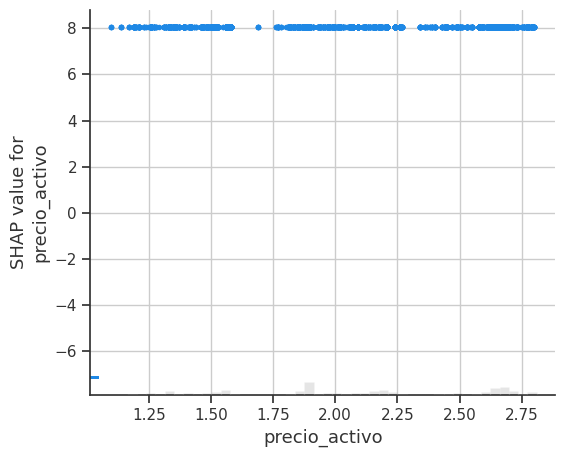

MODELO COMPLETADO


In [52]:
# =========================================
# 1. LIBRERÍAS
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")

# =========================================
# 2. FEATURE ENGINEERING
# =========================================

# Variables activas (multimarca)
df['precio_activo'] = df.apply(lambda x: x[f'precio_marca_{int(x["id_marca"])}'] if x['id_marca'] != 0 else np.nan, axis=1)
df['promo_activa'] = df.apply(lambda x: x[f'promo_marca_{int(x["id_marca"])}'] if x['id_marca'] != 0 else 0, axis=1)

# Features adicionales
df['price_income_ratio'] = df['precio_activo'] / df['ingreso_anual']
df['promo_x_price'] = df['promo_activa'] * df['precio_activo']
df['frecuencia_cliente'] = df.groupby('id')['incidencia_compra'].transform('count')

# =========================================
# 3. VARIABLES DEL MODELO
# =========================================

features = [
    'edad','ingreso_anual','nivel_educacion','ocupacion',
    'precio_activo','promo_activa',
    'price_income_ratio','promo_x_price',
    'ultima_cantidad_comprada','frecuencia_cliente'
]

X = df[features]
y = df['incidencia_compra']

# =========================================
# 4. TRAIN / TEST
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# =========================================
# 5. MODELO XGBOOST
# =========================================
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# =========================================
# 6. PREDICCIONES
# =========================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# =========================================
# 7. MÉTRICAS
# =========================================
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# =========================================
# 8. IMPORTANCIA DE VARIABLES
# =========================================
importances = pd.Series(model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title("Importancia de Variables - XGBoost")
plt.show()

# =========================================
# 9. SHAP (EXPLICABILIDAD)
# =========================================
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

# Dependence plot ejemplo
shap.plots.scatter(shap_values[:, "precio_activo"])

print("MODELO COMPLETADO")

In [53]:
df_resultados = X_test.copy()
df_resultados['probabilidad_compra'] = y_prob
df_resultados['prediccion'] = y_pred

df_resultados.to_csv("predicciones.csv", index=False)

**AGENTE IA**

In [66]:
# =========================================
# 1. LIBRERÍAS
# =========================================
from fastapi import FastAPI
import pandas as pd

# =========================================
# 2. APP
# =========================================
app = FastAPI()

# =========================================
# 3. CARGAR DATOS
# =========================================
df = pd.read_csv("predicciones.csv")

# =========================================
# 4. FUNCIÓN DE FILTRO (AGENTE)
# =========================================
def aplicar_filtros(query, df):

    data = df.copy()
    query = query.lower()

    # Alta probabilidad
    if "alta probabilidad" in query:
        data = data[data['probabilidad_compra'] > 0.7]

    # Baja probabilidad
    if "baja probabilidad" in query:
        data = data[data['probabilidad_compra'] < 0.3]

    # Edad
    if "mayores de" in query:
        try:
            edad = int(query.split("mayores de")[1].split()[0])
            data = data[data['edad'] > edad]
        except:
            pass

    # Promoción
    if "promo" in query:
        data = data[data['promo_activa'] == 1]

    return data.head(10)

# =========================================
# 5. ENDPOINT API
# =========================================
@app.get("/consultar")
def consultar(query: str):
    resultado = aplicar_filtros(query, df)
    return resultado.to_dict(orient="records")



In [67]:
# =========================================
# 6. PRUEBAS LOCALES (IMPORTANTE)
# =========================================
if __name__ == "__main__":

    print("\n--- TEST 1: Alta probabilidad ---")
    r1 = aplicar_filtros("clientes con alta probabilidad", df)
    print(r1)
    if not r1.empty:
        print("Min prob:", r1['probabilidad_compra'].min())

    print("\n--- TEST 2: Mayores de 40 ---")
    r2 = aplicar_filtros("clientes mayores de 40", df)
    print(r2)
    if not r2.empty:
        print("Edad mínima:", r2['edad'].min())

    print("\n--- TEST 3: Promo ---")
    r3 = aplicar_filtros("clientes con promo", df)
    print(r3)
    if not r3.empty:
        print("Promo valores:", r3['promo_activa'].unique())

    print("\n--- TEST 4: Combinado ---")
    r4 = aplicar_filtros("clientes con alta probabilidad y mayores de 40", df)
    print(r4)
    if not r4.empty:
        print("Min prob:", r4['probabilidad_compra'].min())
        print("Edad mínima:", r4['edad'].min())



--- TEST 1: Alta probabilidad ---
    edad  ingreso_anual  nivel_educacion  ocupacion  precio_activo  \
5     52         113619                1          1           1.99   
8     33         116261                1          1           1.94   
9     59         184753                2          1           2.09   
14    43          82082                2          0           1.56   
16    27          64472                1          0           1.34   
20    30          99066                0          1           2.71   
30    37         160642                1          1           1.97   
31    61         166410                2          2           1.98   
33    20         115445                1          1           1.26   
37    27          82357                1          0           1.56   

    promo_activa  price_income_ratio  promo_x_price  ultima_cantidad_comprada  \
5            0.0            0.000018           0.00                         1   
8            0.0            0.00

In [69]:
# =========================================
# TEST AUTOMÁTICO
# =========================================
def test_agente():
    r1 = aplicar_filtros("alta probabilidad", df)
    assert r1.empty or r1['probabilidad_compra'].min() > 0.7

    r2 = aplicar_filtros("mayores de 40", df)
    assert r2.empty or r2['edad'].min() > 40

    r3 = aplicar_filtros("promo", df)
    assert r3.empty or all(r3['promo_activa'] == 1)

    print("\n✅ TODOS LOS TESTS PASARON")

test_agente()


✅ TODOS LOS TESTS PASARON
